In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Load the Titanic dataset 

In [7]:
titanic = sns.load_dataset('titanic')

Display basic information about the dataset

In [8]:
print("Dataset shape:", titanic.shape)
print("\nFirst few rows:")
print(titanic.head())
print("\nDataset info:")
print(titanic.info())
print("\nBasic statistics:")
print(titanic.describe())

Dataset shape: (891, 15)

First few rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       -------

C:\Users\acer\AppData\Local\Temp\ipykernel_13272\3256236212.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Did Not Survive', 'Survived'])


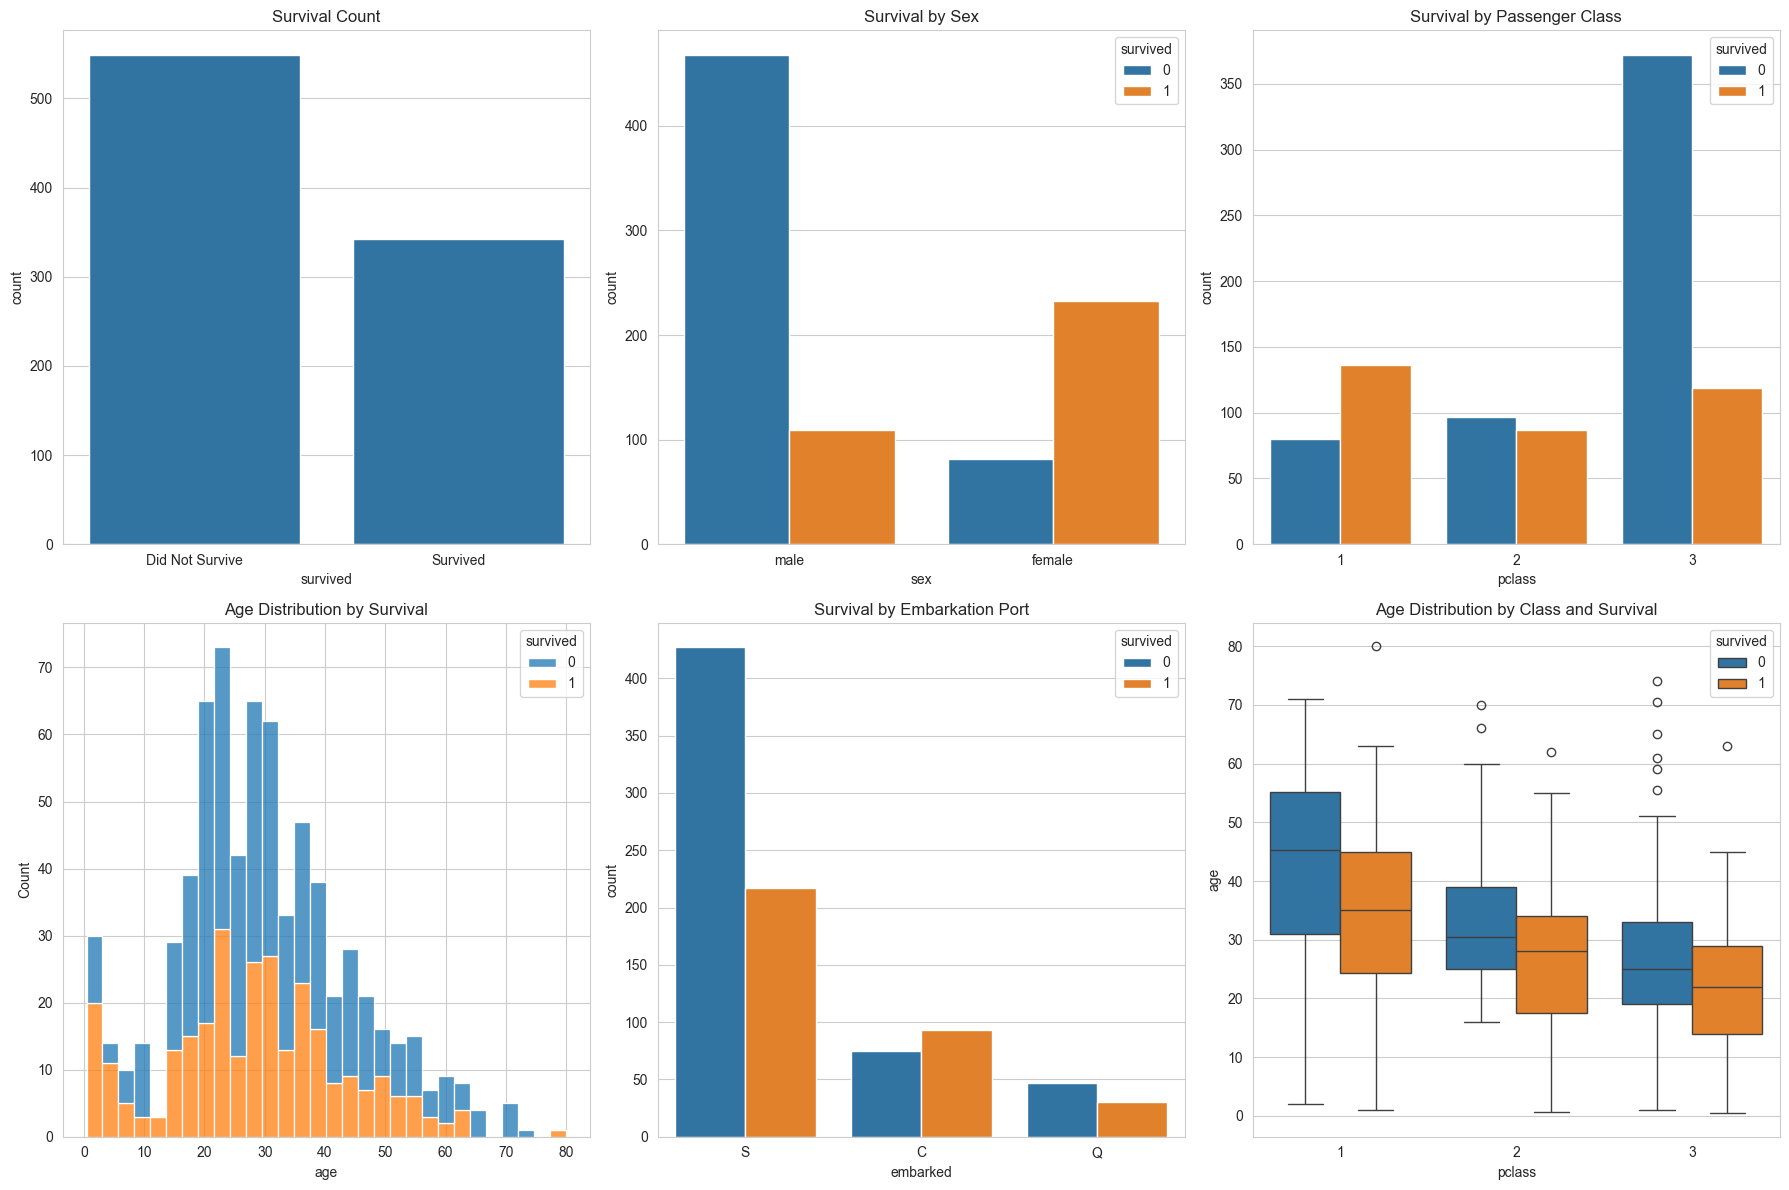

In [10]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Survival count
sns.countplot(data=titanic, x='survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival Count')
axes[0, 0].set_xticklabels(['Did Not Survive', 'Survived'])

# 2. Survival by Sex
sns.countplot(data=titanic, x='sex', hue='survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Sex')

# 3. Survival by Passenger Class
sns.countplot(data=titanic, x='pclass', hue='survived', ax=axes[0, 2])
axes[0, 2].set_title('Survival by Passenger Class')

# 4. Age distribution by Survival
sns.histplot(data=titanic, x='age', hue='survived', multiple='stack', bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution by Survival')

# 5. Survival by Embarkation Port
sns.countplot(data=titanic, x='embarked', hue='survived', ax=axes[1, 1])
axes[1, 1].set_title('Survival by Embarkation Port')

# 6. Box plot of Age by Class and Survival
sns.boxplot(data=titanic, x='pclass', y='age', hue='survived', ax=axes[1, 2])
axes[1, 2].set_title('Age Distribution by Class and Survival')

plt.tight_layout()
plt.show()

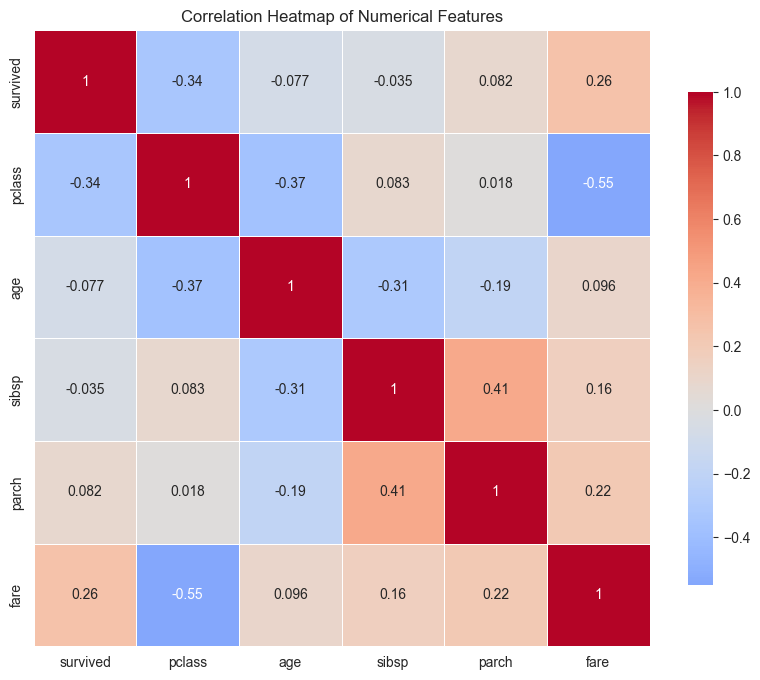

In [11]:
plt.figure(figsize=(10, 8))

# Select numerical columns for correlation
numerical_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
correlation_matrix = titanic[numerical_cols].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

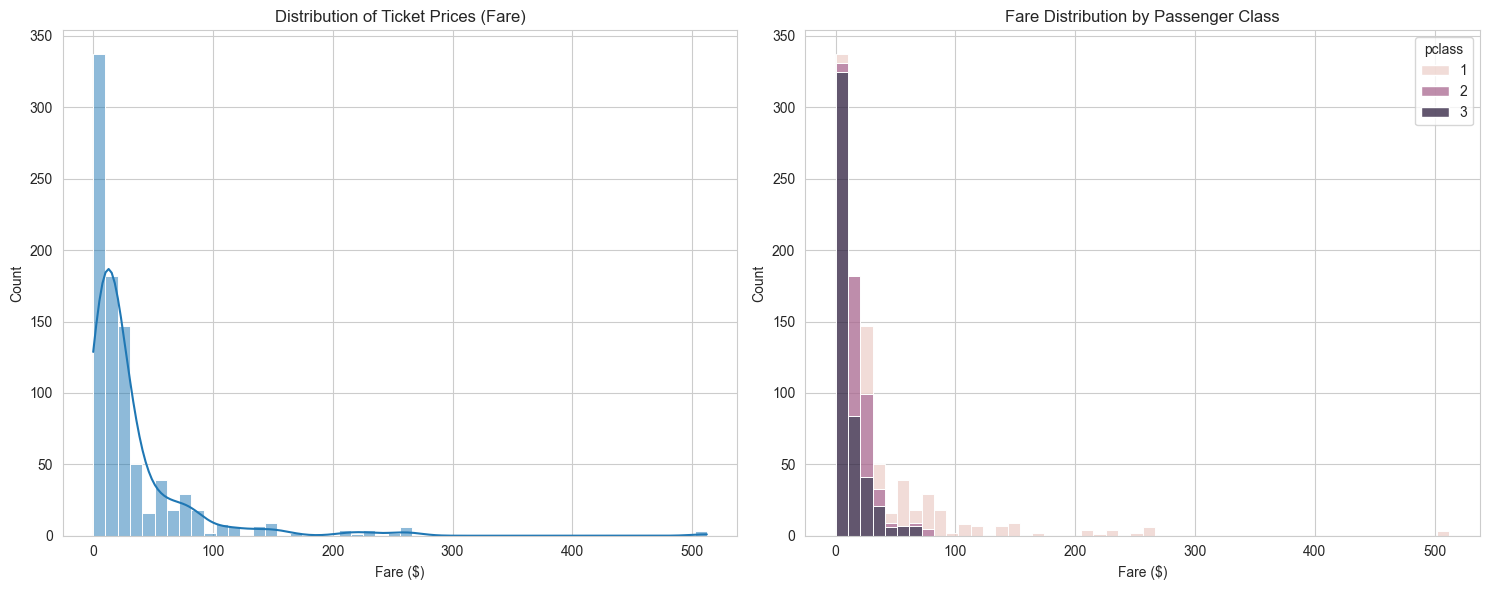

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Basic histogram of fare distribution
sns.histplot(data=titanic, x='fare', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Ticket Prices (Fare)')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Count')

# 2. Fare distribution by Passenger Class
sns.histplot(data=titanic, x='fare', hue='pclass', bins=50, multiple='stack', ax=axes[1])
axes[1].set_title('Fare Distribution by Passenger Class')
axes[1].set_xlabel('Fare ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Fare statistics by Passenger Class:
        count       mean        std  min       25%      50%   75%       max
pclass                                                                     
1       216.0  84.154687  78.380373  0.0  30.92395  60.2875  93.5  512.3292
2       184.0  20.662183  13.417399  0.0  13.00000  14.2500  26.0   73.5000
3       491.0  13.675550  11.778142  0.0   7.75000   8.0500  15.5   69.5500


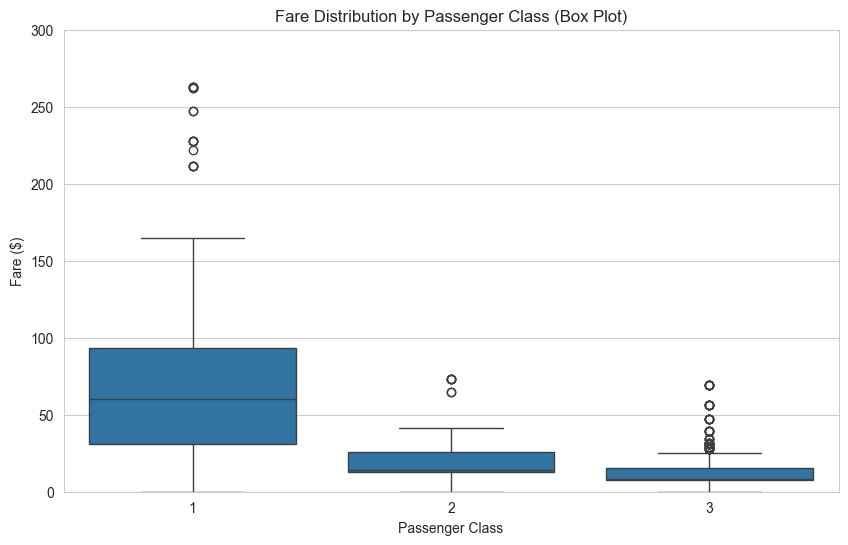

In [14]:
print("Fare statistics by Passenger Class:")
print(titanic.groupby('pclass')['fare'].describe())

# Box plot for fare by class (handles outliers better)
plt.figure(figsize=(10, 6))
sns.boxplot(data=titanic, x='pclass', y='fare')
plt.title('Fare Distribution by Passenger Class (Box Plot)')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.ylim(0, 300)  # Limit y-axis to better visualize the distribution
plt.show()

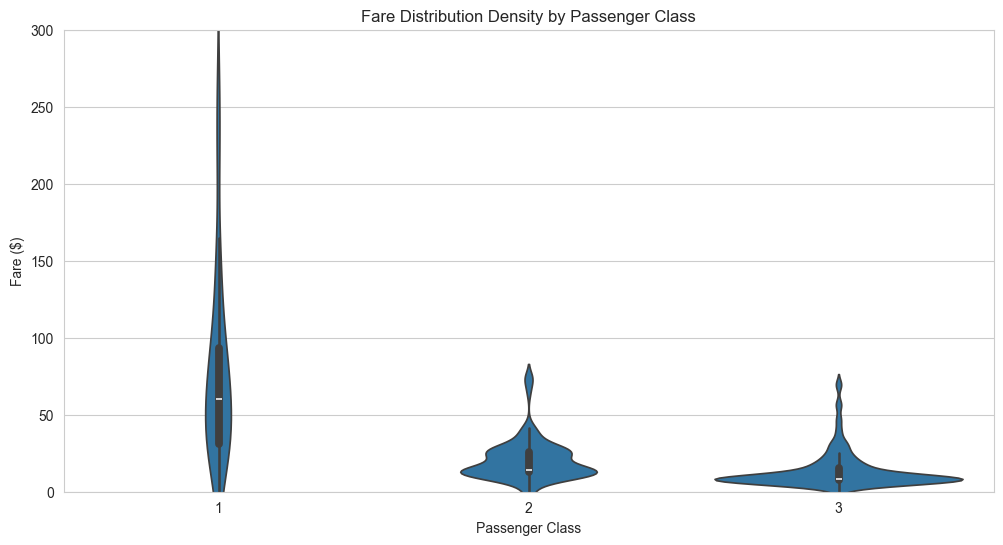

In [15]:
# Violin plot for more detailed distribution shape
plt.figure(figsize=(12, 6))
sns.violinplot(data=titanic, x='pclass', y='fare', inner='box')
plt.title('Fare Distribution Density by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.ylim(0, 300)
plt.show()